# Figure S2: Pilot Metabolic Rate by Time of Day and Wrapping\n
\n
This notebook reproduces the simple pilot boxplot from `data/pilot_exp/prelim_rmr.R` using the shared plotting setup and style system used in Figure 1 notebooks.

## Load data and shared style

In [3]:
from pathlib import Path
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Load shared Figure style + palette (same pattern as Figure1BarChart.ipynb).
style_dir_candidates = [
    Path.cwd() / 'notebooks' / 'styles',
    Path.cwd() / 'styles',
    Path.cwd() / '..' / 'notebooks' / 'styles',
]

style_dir = next(
    (
        p.resolve()
        for p in style_dir_candidates
        if (p / 'photeros.mplstyle').exists() and (p / 'figure_style.py').exists()
    ),
    None,
)

if style_dir is None:
    raise FileNotFoundError('Could not find shared style files in notebooks/styles')

style_path = style_dir / 'photeros.mplstyle'
module_path = style_dir / 'figure_style.py'

spec = importlib.util.spec_from_file_location('figure_style_shared', module_path)
figure_style = importlib.util.module_from_spec(spec)
spec.loader.exec_module(figure_style)

figure_style.apply_photeros_style(style_path)
palette = figure_style.get_palette()

print(f'Shared style loaded from: {style_path}')

pilot_candidates = [
    Path.cwd() / '../data/pilot_exp/prelim_rmr.csv',
    Path.cwd() / 'data/pilot_exp/prelim_rmr.csv',
    Path('/Users/oakley/Documents/GitHub/signal_respirometry/data/pilot_exp/prelim_rmr.csv'),
]

pilot_path = next((p.resolve() for p in pilot_candidates if p.exists()), None)
if pilot_path is None:
    raise FileNotFoundError('Could not find data/pilot_exp/prelim_rmr.csv')

prelim_rmr = pd.read_csv(pilot_path)
print(f'Loaded {len(prelim_rmr)} rows from: {pilot_path}')

Shared style loaded from: /Users/oakley/Documents/GitHub/signal_respirometry/notebooks/styles/photeros.mplstyle
Loaded 16 rows from: /Users/oakley/Documents/GitHub/signal_respirometry/data/pilot_exp/prelim_rmr.csv


In [6]:
# Match factor ordering in the R script.
time_order = ['day', 'night']
wrap_order = ['unwrapped', 'wrapped']

prelim_rmr['time'] = pd.Categorical(prelim_rmr['time'], categories=time_order, ordered=True)
prelim_rmr['wrap'] = pd.Categorical(prelim_rmr['wrap'], categories=wrap_order, ordered=True)

display(prelim_rmr.head())

,box,channel,time,wrap,rmr,avg_temp
0,2,1,day,unwrapped,0.240476,22.585
1,2,2,day,unwrapped,0.839472,22.585
2,2,3,day,wrapped,0.413044,22.585
3,2,4,day,wrapped,0.637238,22.585
4,2,1,night,unwrapped,3.681847,24.050


In [7]:
# Optional model summary equivalent to: lm(rmr ~ time * wrap) in R.
try:
    import statsmodels.formula.api as smf
except ImportError:
    print('statsmodels not installed. Skipping linear model summary.')
else:
    interactive_model = smf.ols('rmr ~ C(time) * C(wrap)', data=prelim_rmr).fit()
    print(interactive_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    rmr   R-squared:                       0.917
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     44.14
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           9.30e-07
Time:                        22:51:57   Log-Likelihood:                -8.2402
No. Observations:                  16   AIC:                             24.48
Df Residuals:                      12   BIC:                             27.57
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

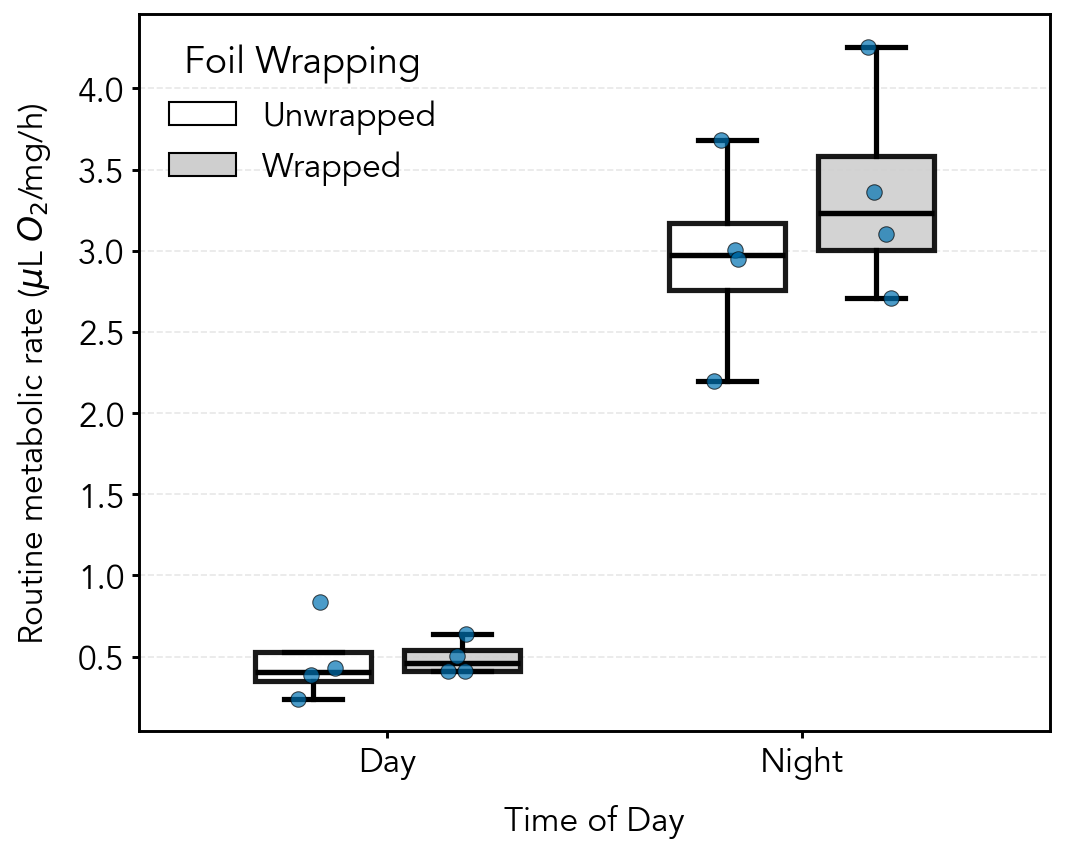

In [12]:
# Figure S2: boxplot styled to match Figure 1 conventions as closely as possible.
time_label = {'day': 'Day', 'night': 'Night'}
wrap_label = {'unwrapped': 'Unwrapped', 'wrapped': 'Wrapped'}

group_positions = []
group_data = []
group_colors = []
group_keys = []

offset = {'unwrapped': -0.18, 'wrapped': 0.18}
box_color = {'unwrapped': 'white', 'wrapped': '#cfcfcf'}

for i, t in enumerate(time_order):
    for w in wrap_order:
        vals = prelim_rmr[(prelim_rmr['time'] == t) & (prelim_rmr['wrap'] == w)]['rmr'].dropna().to_numpy()
        if len(vals) == 0:
            continue
        group_positions.append(i + offset[w])
        group_data.append(vals)
        group_colors.append(box_color[w])
        group_keys.append((t, w))

fig, ax = plt.subplots(figsize=(7.2, 5.8))
bp = ax.boxplot(
    group_data,
    positions=group_positions,
    widths=0.28,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(color='black', linewidth=2.5),
    whiskerprops=dict(color='black', linewidth=2.5),
    capprops=dict(color='black', linewidth=2.5),
    medianprops=dict(color='black', linewidth=2.6),
)

for patch, c in zip(bp['boxes'], group_colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.9)

# Overlay points (Figure 1 style) using shared palette dark blue.
point_color = palette.get('dark_blue', '#0072B2')
for pos, (t, w), vals in zip(group_positions, group_keys, group_data):
    x_data = np.random.normal(pos, 0.025, size=len(vals))
    ax.scatter(
        x_data,
        vals,
        alpha=0.7,
        s=55,
        c=point_color,
        edgecolors='black',
        linewidth=0.5,
        zorder=3,
    )

ax.set_xticks(np.arange(len(time_order)))
ax.set_xticklabels([time_label[t] for t in time_order])
ax.set_xlabel('Time of Day', fontsize=16, fontweight='bold', labelpad=12)
ax.set_ylabel(r'Routine metabolic rate ($\mu$L $O_2$/mg/h)', fontsize=16, fontweight='bold', labelpad=12)
ax.tick_params(axis='both', labelsize=16, width=1.4)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Keep x-limits compact around day/night groups, similar to Figure 1 spacing choices.
ax.set_xlim(-0.6, 1.6)

legend_handles = [
    Patch(facecolor='white', edgecolor='black', label=wrap_label['unwrapped']),
    Patch(facecolor='#cfcfcf', edgecolor='black', label=wrap_label['wrapped']),
]
ax.legend(handles=legend_handles, title='Foil Wrapping', frameon=False, loc='upper left', fontsize=16, title_fontsize=18)

plt.tight_layout()
plt.show()

In [ ]:
# Save Figure S2 to files
figures_dir = Path.cwd() / '../figures'
figures_dir.mkdir(parents=True, exist_ok=True)

if 'fig' in locals():
    png_path = (figures_dir / 'FigureS2_Pilot.png').resolve()
    pdf_path = (figures_dir / 'FigureS2_Pilot.pdf').resolve()

    fig.savefig(png_path, dpi=600, bbox_inches='tight')
    fig.savefig(pdf_path, bbox_inches='tight')

    print(f'Saved PNG: {png_path}')
    print(f'Saved PDF: {pdf_path}')
else:
    print('No figure object found. Run the plotting cell first.')